#**Real-Time User Behavior Modeling System for Cybersecurity Using Machine Learning**

**Introduction**

The User Behavior Modeling System is a cybersecurity project designed to detect unusual behavior among users in real time. Cyberattackers often exploit legitimate login credentials to bypass standard security protocols, making it challenging for traditional antivirus systems to detect these intrusions. This project uses machine learning, specifically anomaly detection, to identify deviations in users’ login/logout patterns and session behaviors, alerting the cybersecurity team to potential threats.

**Project Need**

With attackers leveraging user credentials, businesses require advanced methods to detect unauthorized access. User behavior modeling is essential for tracking typical login times, session durations, and access patterns to create a behavioral profile for each user. By identifying deviations from these profiles, the system helps to spot potential intrusions that standard defenses may miss.

**Tools Used**

- **Google Colab**: Used as the development environment for code execution and model training.
- **Python Libraries**: Libraries such as `pandas` for data manipulation, `sklearn` for machine learning, and `pickle` for model serialization.
- **Isolation Forest**: An unsupervised anomaly detection algorithm that identifies outliers, used to flag suspicious user behavior.
- **Simulated Data**: Synthetic datasets for login/logout patterns and session details to emulate real-world user behavior.



# Loading the CSV File and Initial Data Exploration

In [18]:
# Step 1: Load the CSV file
import pandas as pd

In [19]:
from google.colab import files
uploaded = files.upload()

Saving user_behavior_data.csv to user_behavior_data (1).csv


In [20]:
# Load the dataset
df = pd.read_csv('user_behavior_data.csv', parse_dates=["LoginTime", "LogoutTime"])

In [23]:
# Display the first few rows to understand the structure
print("Data Preview:")
print(df.head())

Data Preview:
   UserID                     LoginTime                    LogoutTime  \
0  User_1 2024-01-01 07:29:53.377711402 2024-01-01 15:09:11.378232931   
1  User_1 2024-01-02 08:55:40.712762084 2024-01-02 14:07:06.906563849   
2  User_1 2024-01-03 06:37:26.668422371 2024-01-03 08:42:57.730334843   
3  User_1 2024-01-04 06:13:56.404015222 2024-01-04 13:17:44.042888750   
4  User_1 2024-01-05 08:24:16.056169102 2024-01-05 14:21:39.485129562   

   SessionDuration  
0         7.655000  
1         5.190556  
2         2.091944  
3         7.063056  
4         5.956389  


In [22]:
# Checking for any null values or data anomalies
print("\nData Info:")
print(df.info())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   UserID           3000 non-null   object        
 1   LoginTime        3000 non-null   datetime64[ns]
 2   LogoutTime       3000 non-null   datetime64[ns]
 3   SessionDuration  3000 non-null   float64       
dtypes: datetime64[ns](2), float64(1), object(1)
memory usage: 93.9+ KB
None


 **Exploratory Data Analysis (EDA)**



In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

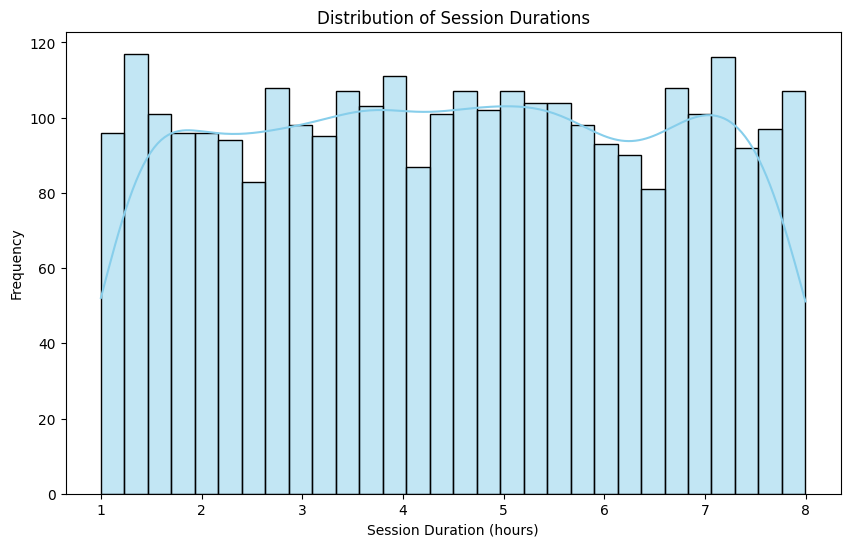

In [29]:
# Distribution of session durations
plt.figure(figsize=(10, 6))
sns.histplot(df['SessionDuration'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Session Durations")
plt.xlabel("Session Duration (hours)")
plt.ylabel("Frequency")
plt.show()


In [30]:
if 'LoginHour' not in df.columns:
    df['LoginTime'] = pd.to_datetime(df['LoginTime'], errors='coerce')
    df['LoginHour'] = df['LoginTime'].dt.hour

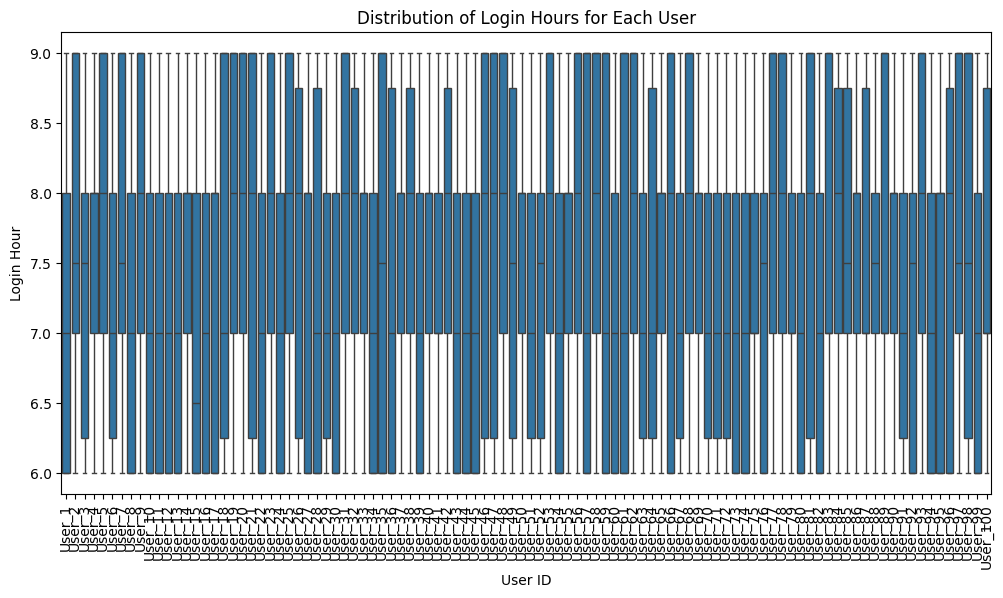

In [31]:
# Average login hour per user
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='UserID', y='LoginHour')
plt.xticks(rotation=90)
plt.title("Distribution of Login Hours for Each User")
plt.xlabel("User ID")
plt.ylabel("Login Hour")
plt.show()


# Feature Engineering


In [32]:
# Calculate additional features
df['LoginHour'] = df['LoginTime'].dt.hour  # Extract login hour as a feature
user_features = df.groupby('UserID').agg(
    avg_login_hour=('LoginHour', 'mean'),
    avg_session_duration=('SessionDuration', 'mean')
).reset_index()

In [33]:
# Merge these features back into the main DataFrame
df = df.merge(user_features, on='UserID')
df['LoginDeviation'] = abs(df['LoginHour'] - df['avg_login_hour'])
df['DurationDeviation'] = abs(df['SessionDuration'] - df['avg_session_duration'])

In [34]:
# Saving processed data to a new CSV file (optional, for further inspection)
df.to_csv('processed_data.csv', index=False)
print("Feature engineering completed and processed data saved to 'processed_data.csv'.")

Feature engineering completed and processed data saved to 'processed_data.csv'.


**Visualizing Deviations**

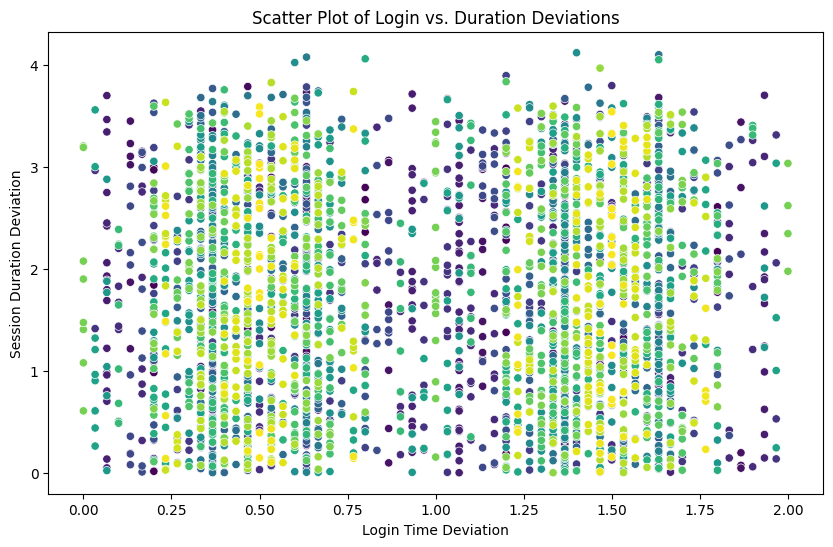

In [35]:
# Scatter plot of login and session duration deviations
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='LoginDeviation', y='DurationDeviation', hue='UserID', palette='viridis', legend=None)
plt.title("Scatter Plot of Login vs. Duration Deviations")
plt.xlabel("Login Time Deviation")
plt.ylabel("Session Duration Deviation")
plt.show()


# Model Training (Isolation Forest for Anomaly Detection)

In [36]:
from sklearn.ensemble import IsolationForest
import pickle

In [37]:
# Step 3: Model Training
# Selecting relevant features for anomaly detection
features = df[['LoginDeviation', 'DurationDeviation']]

In [38]:
# Initialize and train the Isolation Forest model
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(features)

IsolationForest(contamination=0.05, random_state=42)

In [39]:
# Save the trained model to a file
with open('user_behavior_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model training completed and saved as 'user_behavior_model.pkl'.")


Model training completed and saved as 'user_behavior_model.pkl'.


**Anomaly Detection Results**

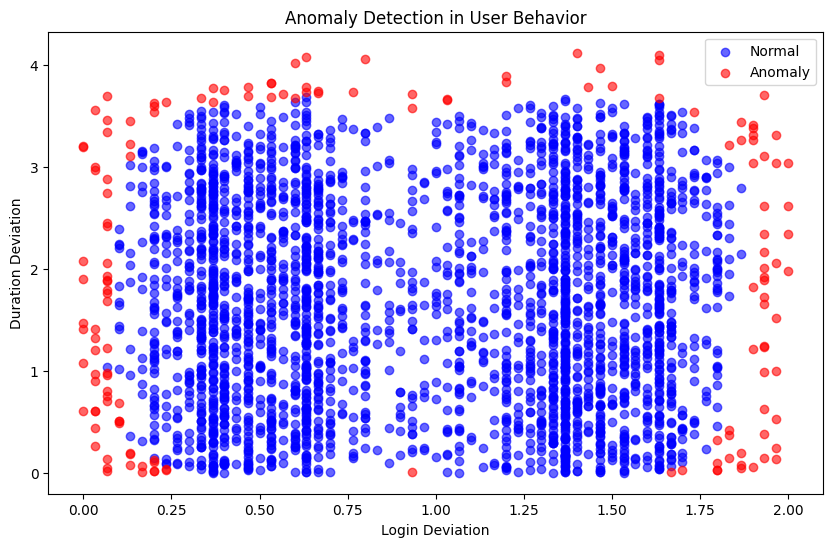

In [42]:
if 'Anomaly' not in df.columns:
    from sklearn.ensemble import IsolationForest

    features = df[['LoginDeviation', 'DurationDeviation']]

    # Train Isolation Forest model
    model = IsolationForest(contamination=0.05, random_state=42)
    df['Anomaly'] = model.fit_predict(features)

    df['Anomaly'] = df['Anomaly'].apply(lambda x: 1 if x == -1 else 0)

anomalies = df[df['Anomaly'] == 1]
normal = df[df['Anomaly'] == 0]

# Plot the anomalies vs normal points
plt.figure(figsize=(10, 6))
plt.scatter(normal['LoginDeviation'], normal['DurationDeviation'], c='blue', label='Normal', alpha=0.6)
plt.scatter(anomalies['LoginDeviation'], anomalies['DurationDeviation'], c='red', label='Anomaly', alpha=0.6)
plt.title("Anomaly Detection in User Behavior")
plt.xlabel("Login Deviation")
plt.ylabel("Duration Deviation")
plt.legend()
plt.show()


# Real-Time Monitoring Simulation

In [41]:
import time

In [43]:
# Step 4: Real-Time Monitoring Simulation
# Load processed data and trained model
df = pd.read_csv('processed_data.csv')
with open('user_behavior_model.pkl', 'rb') as f:
    model = pickle.load(f)

In [44]:
# Extract features and simulate anomaly detection
features = df[['LoginDeviation', 'DurationDeviation']]
df['Anomaly'] = model.predict(features)
df['Anomaly'] = df['Anomaly'].apply(lambda x: 1 if x == -1 else 0)  # 1 for anomaly, 0 for normal


# Real-Time Monitoring Simulation

Simulate real-time anomaly detection by iterating over each user’s session data and predicting anomalies. For this simulation, we’ll read from the processed_data.csv file created after feature engineering.

In [45]:
# Simulated real-time data processing
for index, row in df.iterrows():
    user = row['UserID']
    login_time = row['LoginTime']
    anomaly = row['Anomaly']

    if anomaly == 1:
        print(f"ALERT: Unusual behavior detected for {user} at {login_time}")

    # Simulate a short delay to mimic real-time monitoring
    time.sleep(0.1)


ALERT: Unusual behavior detected for User_1 at 2024-01-09 07:13:01.088298617
ALERT: Unusual behavior detected for User_1 at 2024-01-24 07:14:48.639495687
ALERT: Unusual behavior detected for User_3 at 2024-01-10 07:27:16.266274261
ALERT: Unusual behavior detected for User_5 at 2024-01-08 06:40:40.695552279
ALERT: Unusual behavior detected for User_5 at 2024-01-11 08:27:36.104064468
ALERT: Unusual behavior detected for User_5 at 2024-01-12 06:33:37.209819405
ALERT: Unusual behavior detected for User_5 at 2024-01-18 08:02:43.330543597
ALERT: Unusual behavior detected for User_5 at 2024-01-23 08:18:47.234030344
ALERT: Unusual behavior detected for User_5 at 2024-01-26 06:07:19.203599122
ALERT: Unusual behavior detected for User_5 at 2024-01-28 06:30:29.671382187
ALERT: Unusual behavior detected for User_5 at 2024-01-30 08:29:29.622851793
ALERT: Unusual behavior detected for User_7 at 2024-01-06 06:24:11.203219834
ALERT: Unusual behavior detected for User_7 at 2024-01-24 07:33:24.504173771

**Conclusion**

This project successfully demonstrates how machine learning can enhance cybersecurity through real-time anomaly detection. The User Behavior Modeling System effectively builds behavior profiles and alerts on deviations, offering an extra layer of security. This model showcases the potential for machine learning to improve early detection of cyber threats, making organizational networks more secure and resilient against credential-based attacks.